# Applied_ML_Audio_Recognition 
# Exploratory Data Analysis

- Author: [Nathan Sloss](https://github.com/nwn8)
- Repository: [Project Github Repo](https://github.com/nwn8/Applied_ML_Audio_Recognition)

This notebook is for Exploratory Data Analysis created in the songs database.

## 1. Imports

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt
import sqlite3

# Axes object (basic plot type returned by Seaborn)
from matplotlib.axes import Axes


## 2. Load Data

In [26]:
# Connect to your SQLite database
conn = sqlite3.connect("songs_database.db")

# Load each table into a DataFrame
songs_df = pd.read_sql_query("SELECT * FROM songs", conn)
fingerprints_df = pd.read_sql_query("SELECT * FROM fingerprints", conn)
audio_features_df = pd.read_sql_query("SELECT * FROM audio_features", conn)

# Preview the data
print("Songs and Lyrics Table")
print(songs_df.head())
print("---------------------------------------------")
print("Fingerprints Table")
print(fingerprints_df.head())
print("---------------------------------------------")
print("Audio Features Table")
print(audio_features_df.head())

# Close connection when done
conn.close()

Songs and Lyrics Table
   song_id               title  duration  \
0        1   Shattered Compass     258.0   
1        2          smoke love     173.0   
2        3             So Free     272.0   
3        4  the days are black     198.0   
4        5           the Walls     280.0   

                                              lyrics  word_count  \
0  Born in a state raised in the hate Every answe...         175   
1  Ooh, ooh, ooh...삈, z Edward Velvet smoke in th...         136   
2  your This is all you, you know I do Walk by, t...          71   
3  Dance The darkness crumbles all around you So ...          52   
4                                                              0   

   unique_word_count                                          word_freq  \
0                103  {"born": 1, "state": 1, "raised": 1, "hate": 1...   
1                 81  {"ooh": 3, "edward": 1, "velvet": 2, "smoke": ...   
2                 19  {"all": 1, "know": 14, "walk": 1, "take": 1, "...   
3  

## 3. Data Inspection - Songs Table

In [27]:
# Specify the number of rows to display
songs_df.head(10)

# Inspect the shape of the DataFrame with shape attribute
# The shape is a tuple with count of rows and columns in the DataFrame
songs_df.shape

# Inspect the data types of the columns with dtypes attribute
# The data types are returned as a pandas Series
songs_df.dtypes

# Inspect the data types of the columns with info() method
songs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   song_id            42 non-null     int64  
 1   title              42 non-null     str    
 2   duration           42 non-null     float64
 3   lyrics             42 non-null     str    
 4   word_count         42 non-null     int64  
 5   unique_word_count  42 non-null     int64  
 6   word_freq          42 non-null     str    
 7   cleaned_lyrics     42 non-null     str    
dtypes: float64(1), int64(3), str(4)
memory usage: 2.8 KB


## 3. Data Inspection - Features Table

In [28]:
# Specify the number of rows to display
fingerprints_df.head(10)

# Inspect the shape of the DataFrame with shape attribute
# The shape is a tuple with count of rows and columns in the DataFrame
fingerprints_df.shape

# Inspect the data types of the columns with dtypes attribute
# The data types are returned as a pandas Series
fingerprints_df.dtypes

# Inspect the data types of the columns with info() method
fingerprints_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   fingerprint_id  42 non-null     int64
 1   song_id         42 non-null     int64
 2   fingerprint     42 non-null     str  
dtypes: int64(2), str(1)
memory usage: 1.1 KB


## 3. Data Inspection - Audio Features Table

In [29]:
# Specify the number of rows to display
audio_features_df.head(10)

# Inspect the shape of the DataFrame with shape attribute
# The shape is a tuple with count of rows and columns in the DataFrame
audio_features_df.shape

# Inspect the data types of the columns with dtypes attribute
# The data types are returned as a pandas Series
audio_features_df.dtypes

# Inspect the data types of the columns with info() method
audio_features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_id  42 non-null     int64  
 1   song_id     42 non-null     int64  
 2   tempo       42 non-null     float64
 3   mfcc_1      42 non-null     float64
 4   mfcc_2      42 non-null     float64
 5   mfcc_3      42 non-null     float64
 6   mfcc_4      42 non-null     float64
 7   mfcc_5      42 non-null     float64
 8   mfcc_6      42 non-null     float64
 9   mfcc_7      42 non-null     float64
 10  mfcc_8      42 non-null     float64
 11  mfcc_9      42 non-null     float64
 12  mfcc_10     42 non-null     float64
 13  mfcc_11     42 non-null     float64
 14  mfcc_12     42 non-null     float64
 15  mfcc_13     42 non-null     float64
 16  mfcc_14     42 non-null     float64
 17  mfcc_15     42 non-null     float64
 18  mfcc_16     42 non-null     float64
 19  mfcc_17     42 non-null     float64
 20  m

## Data Inspection Summary

We can see that all 42 songs created data in each of the correct tables.  

## 4. Initial Descriptive Statistics - Songs Table (Duration, Word Count, Unique Word Count)

In [30]:
# Inspect summary statistics for numerical columns
songs_df.describe()

,song_id,duration,word_count,unique_word_count
count,42.000000,42.000000,42.000000,42.000000
mean,21.500000,229.428571,91.571429,53.357143
std,12.267844,67.626717,52.721608,29.803275
min,1.000000,104.000000,0.000000,0.000000
25%,11.250000,181.750000,55.000000,31.750000
50%,21.500000,229.500000,83.500000,45.000000
75%,31.750000,275.750000,134.750000,81.000000
max,42.000000,427.000000,225.000000,104.000000


## 4. Initial Descriptive Statistics Summary

The mean word count for all of the data was 42 after all stopwords are removed.  Some songs have no words which is okay as it is simply a fault of the Whisper program capabality and one small feature.  As long as the Whisper program always produces 0 lyrics for the same song it will not effect the ML model.  

## 5. Initial Data Distribution for Numerical Columns - Songs Table

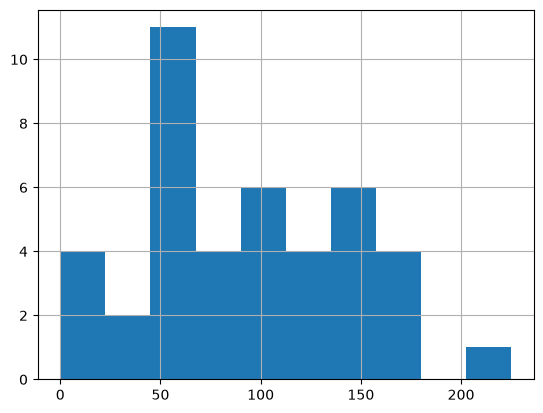

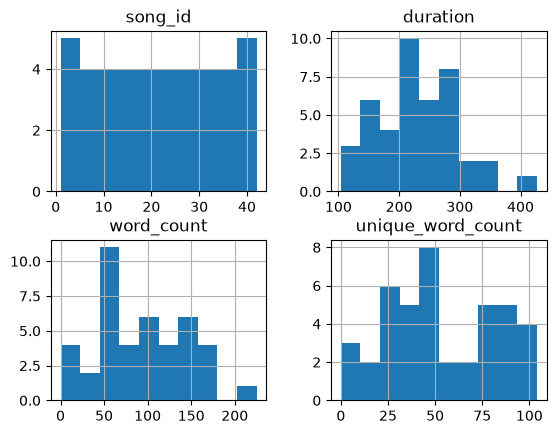

In [31]:
# Inspect histogram by one numerical column
songs_df['word_count'].hist()

# Inspect histograms for ALL numerical columns
songs_df.hist()

# Show all plots
matplotlib.pyplot.show()

###  Observations

Durateion, word count, and unique word count are distributed differently enough to provide unique feature set per song. 

## 5. Initial Data Distribution for Numerical Columns - Audio Features Table

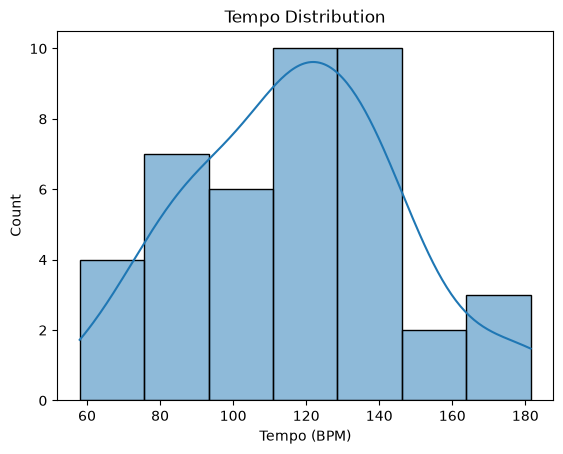

In [32]:
sns.histplot(audio_features_df["tempo"], kde=True)
plt.title("Tempo Distribution")
plt.xlabel("Tempo (BPM)")
plt.show()

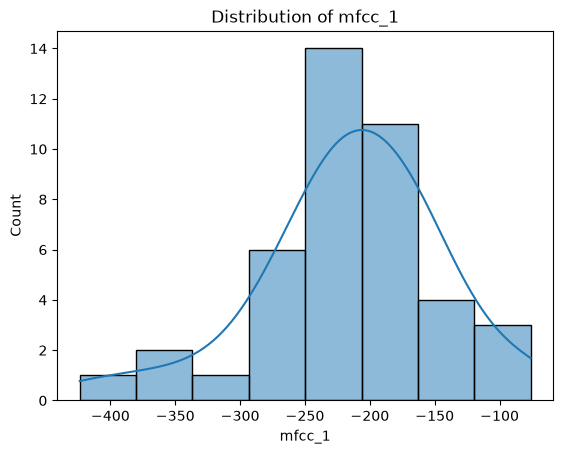

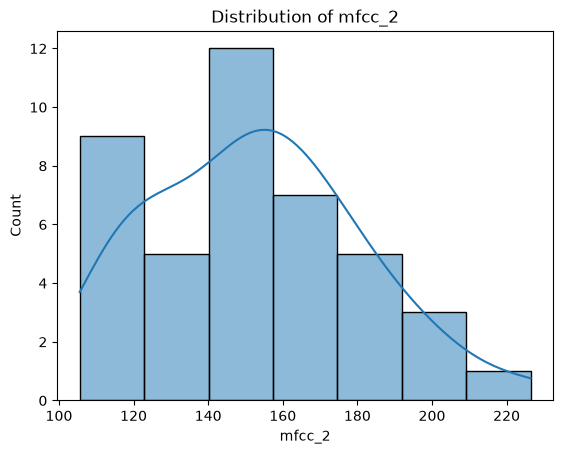

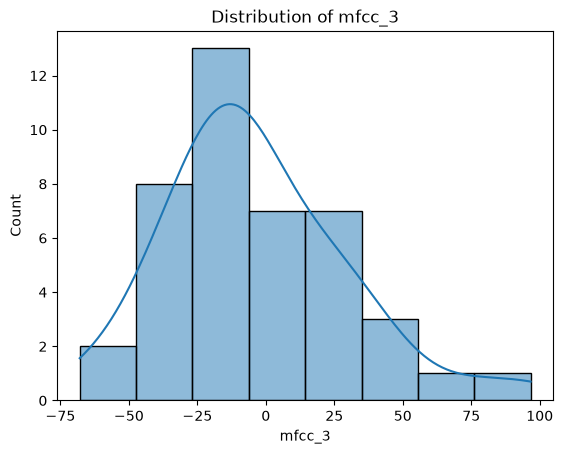

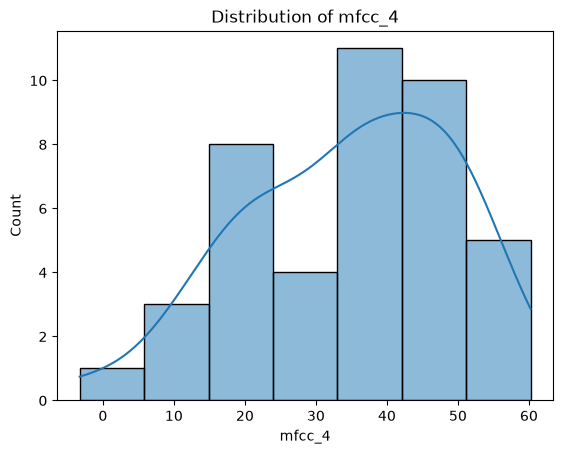

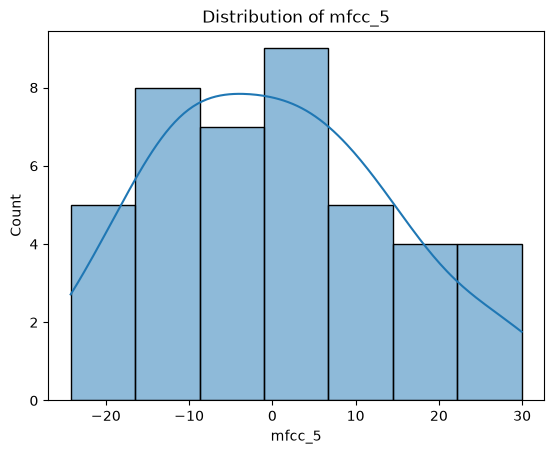

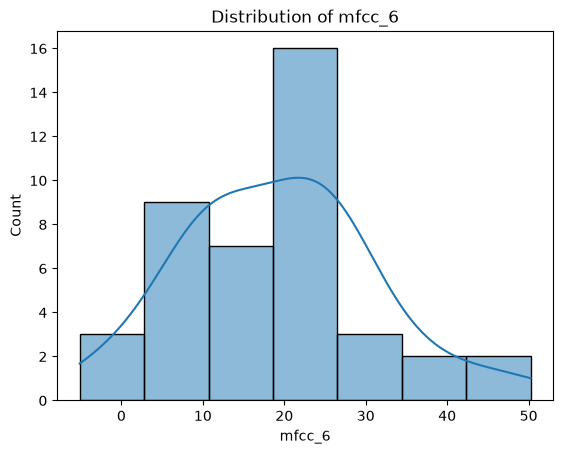

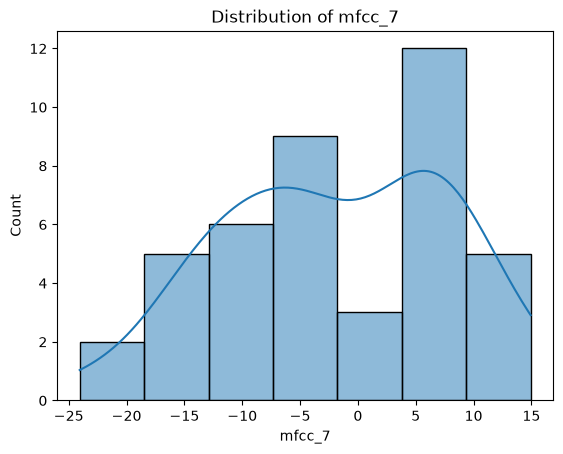

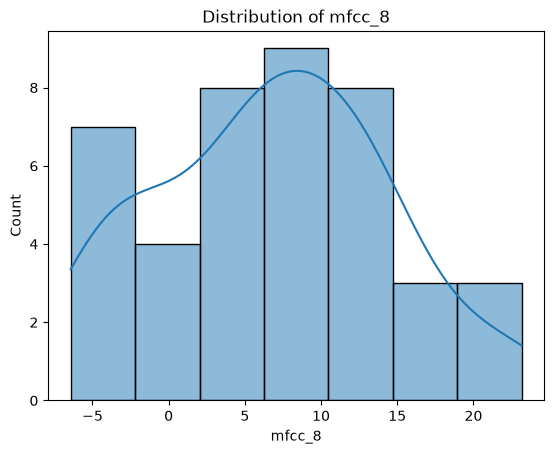

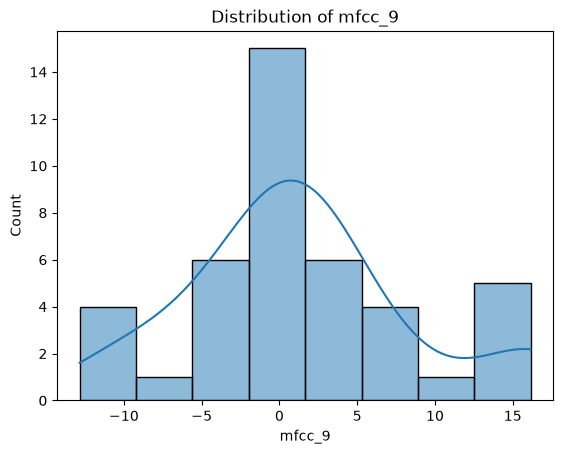

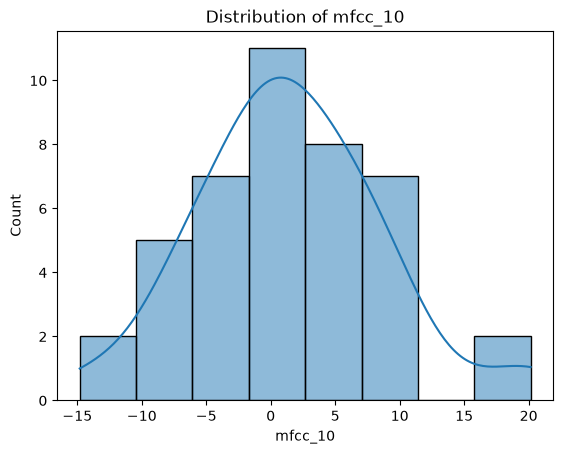

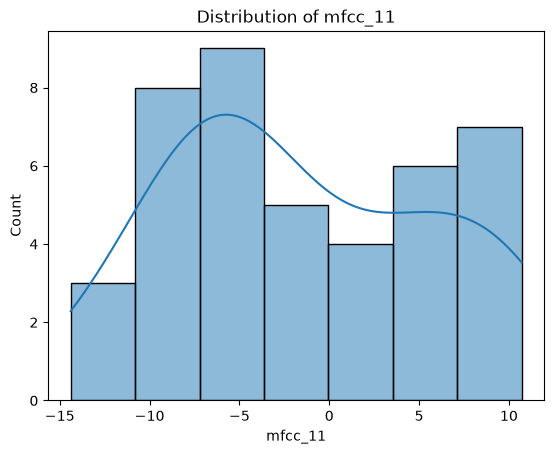

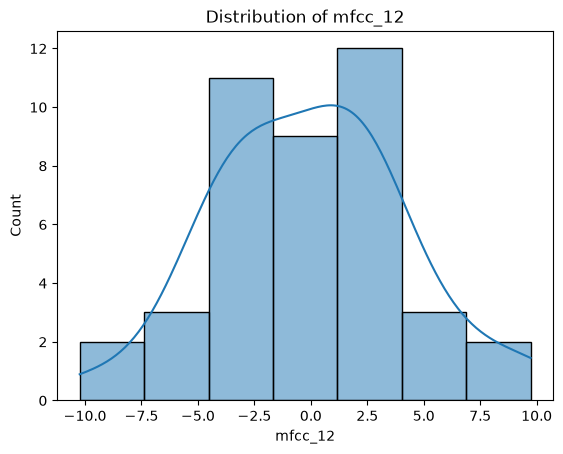

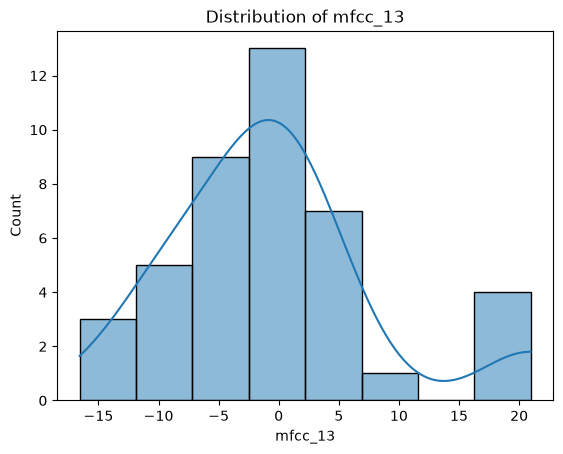

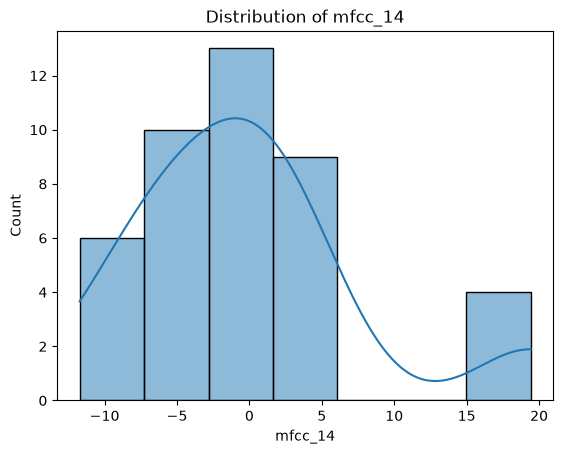

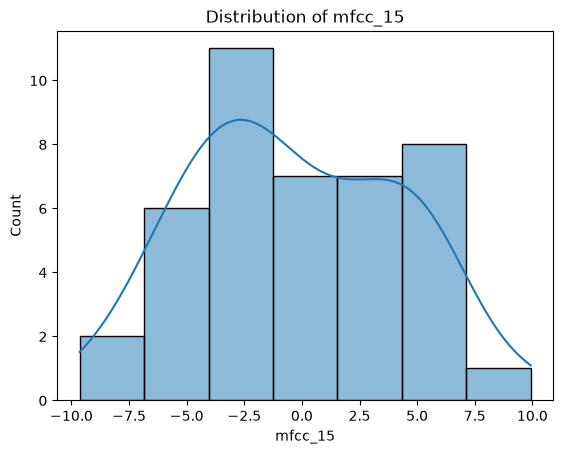

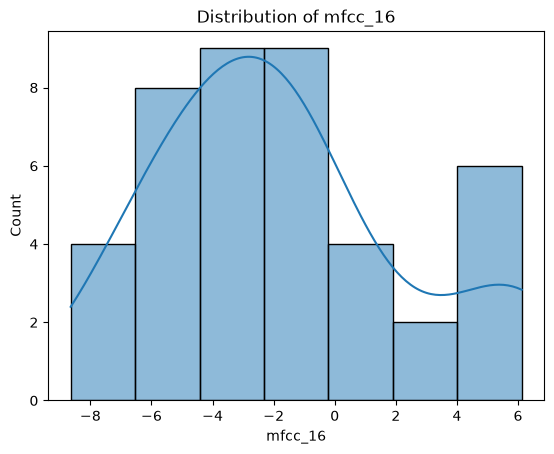

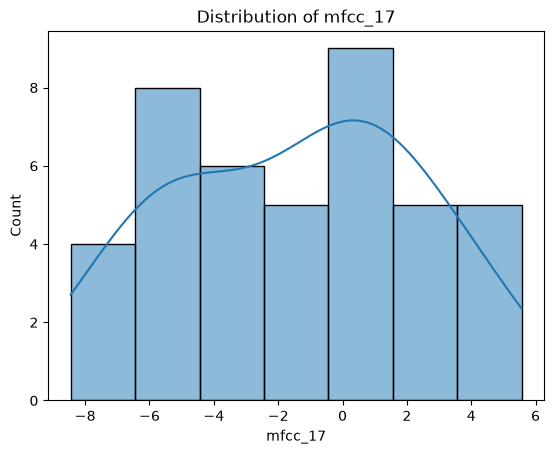

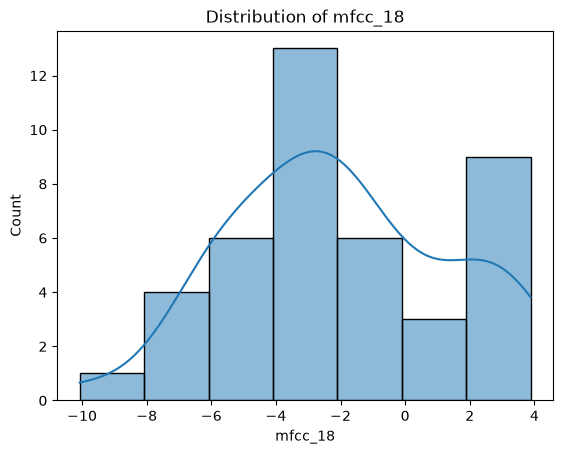

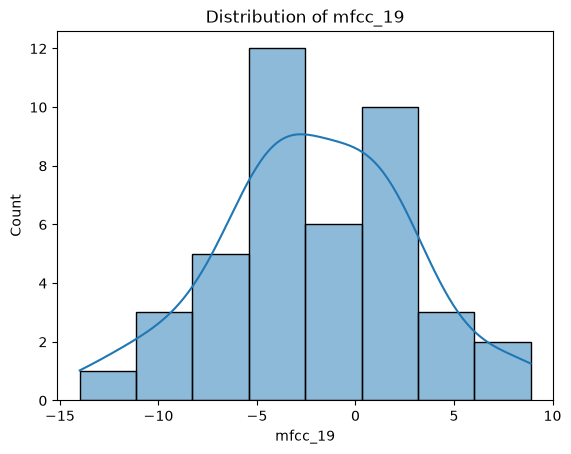

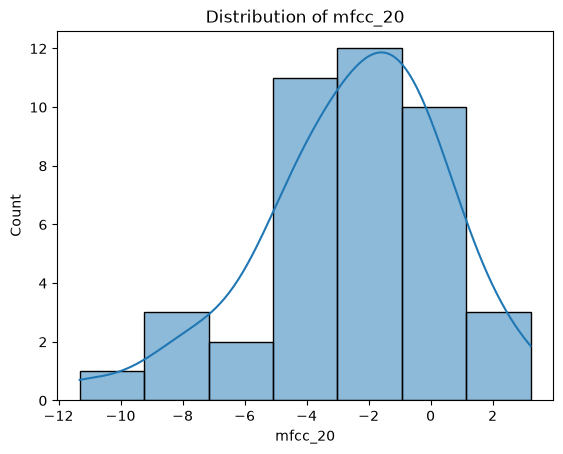

In [33]:
mfcc_cols = [col for col in audio_features_df.columns if col.startswith("mfcc_")]

for col in mfcc_cols:
    sns.histplot(audio_features_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

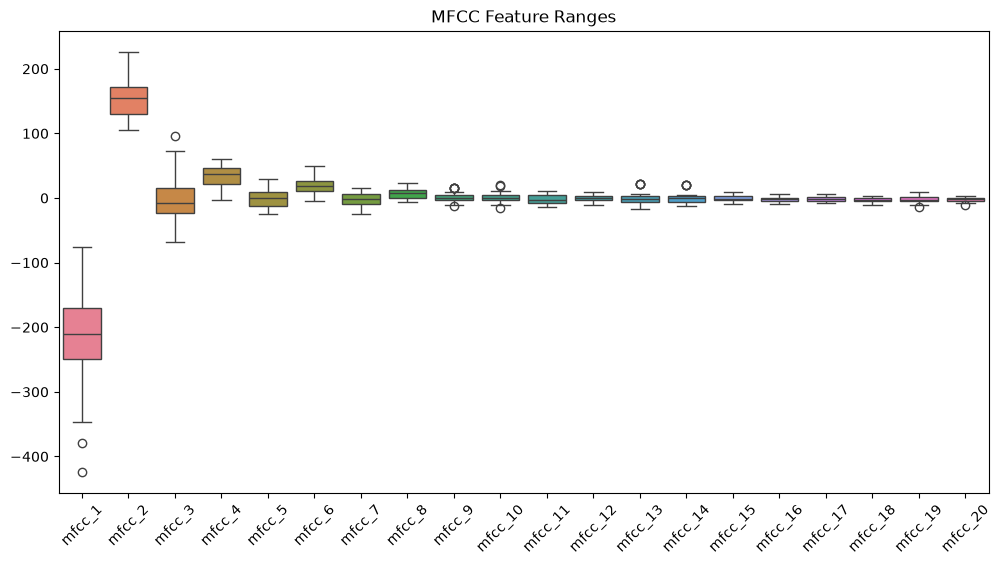

In [34]:
plt.figure(figsize=(12,6))
sns.boxplot(data=audio_features_df[mfcc_cols])
plt.xticks(rotation=45)
plt.title("MFCC Feature Ranges")
plt.show()

## Observations

We can see that the first 7 mfcc ranges offer more diverse data for unique characteristics of each song.  Its possible that mfcc 12 - 20 could produce worse results in the ML model.

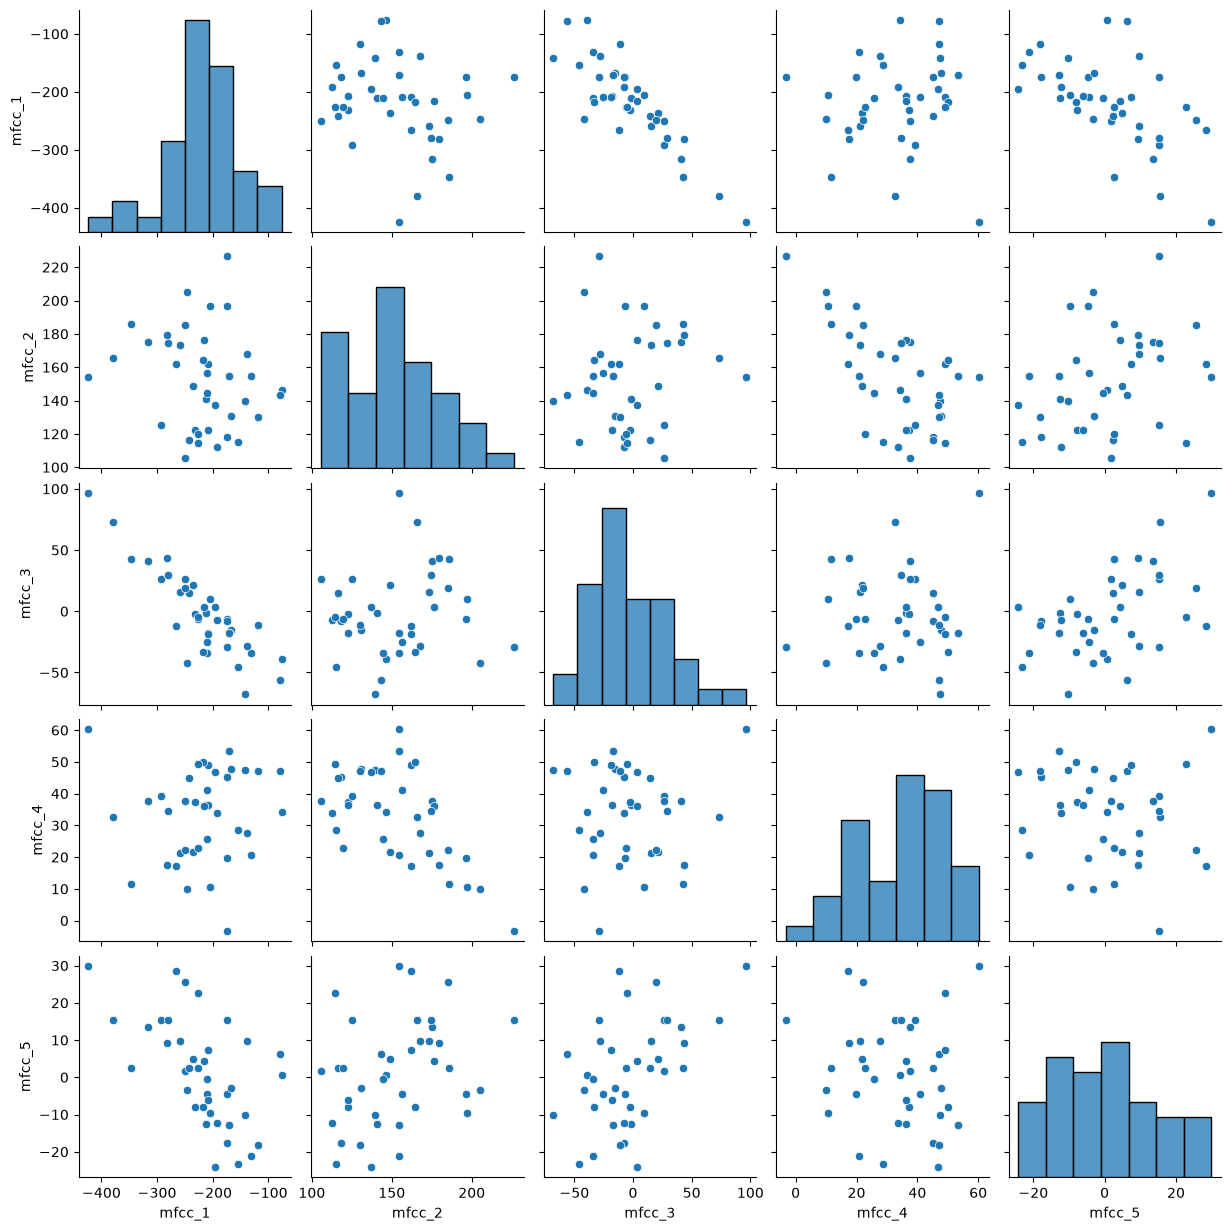

In [35]:
sns.pairplot(audio_features_df[mfcc_cols[:5]])  # first 5 MFCCs to keep it manageable
plt.show()

## Observations

We can see that there is a wide dispersion for each category compared to othe rcategories.  Because we are trying to determine one unique song within the dataset this is better for our predictive model than a tight correlation.  

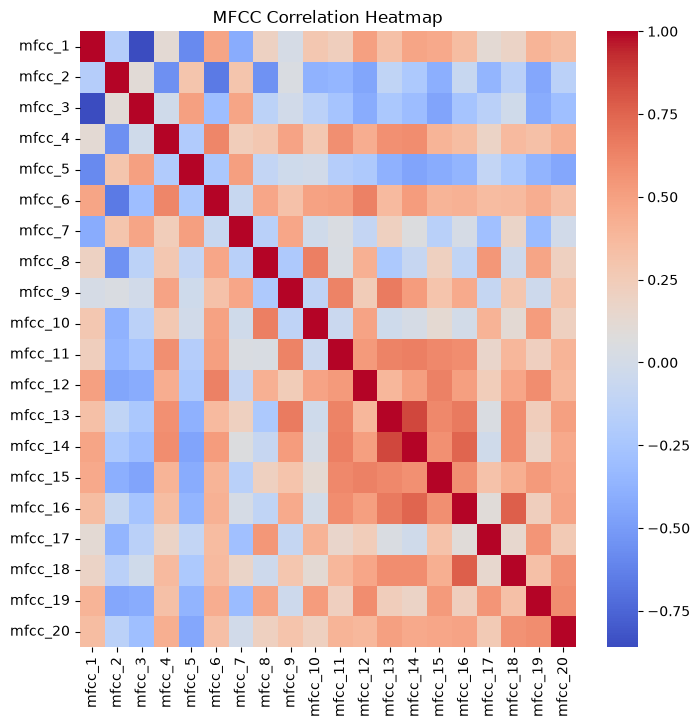

In [36]:
plt.figure(figsize=(8,8))
sns.heatmap(audio_features_df[mfcc_cols].corr(), annot=False, cmap="coolwarm")
plt.title("MFCC Correlation Heatmap")
plt.show()

## Understanding MFCC Data

Lower MFCCs (1–5) often correlate with each other
→ They describe broad spectral shape (overall timbre).

Mid MFCCs (6–13) may show mixed correlations
→ They capture more detailed spectral curvature.

Higher MFCCs (14–20) often correlate less
→ They represent fine-grained, noisy, or high-frequency details.

Blue blocks represent spectral data that moves in opposite directions. These are contrasting spectral behavior within the song.

MFCC_17 barely correlates with anything.  its capturing a unique acoustic charactaristic to that particular song.  

Future development could use MFCC_17 to classify music into different genres.
